In [165]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Prédiction des Prix Immobiliers à Bengaluru, Inde

## Introduction

Le marché immobilier de Bengaluru (anciennement Bangalore) est l'un des plus dynamiques de l'Inde, porté par le statut de la ville comme hub technologique majeur du pays. La prédiction des prix immobiliers dans cette métropole représente un défi intéressant en science des données, compte tenu de la complexité et de la variabilité du marché local.

Ce projet vise à développer un modèle de régression capable de prédire les prix des biens immobiliers à Bengaluru en se basant sur différentes caractéristiques telles que la localisation, la surface habitable, le nombre de chambres, et d'autres facteurs pertinents. Cette analyse permettra non seulement d'aider les acheteurs et vendeurs potentiels à mieux évaluer les biens, mais aussi de comprendre les facteurs qui influencent le plus les prix de l'immobilier dans cette ville en pleine expansion.

Les objectifs principaux de cette étude sont :
- Analyser les tendances du marché immobilier à Bengaluru
- Identifier les variables les plus influentes sur les prix
- Développer un modèle de prédiction précis et fiable
- Fournir des insights utiles pour les acteurs du marché immobilier


## Importation de la base de donnees & des packages

In [ ]:
# packages
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Base de donnees sur kaggle
# df = pd.read_csv(
#     "/kaggle/input/bengaluru-house-price-data/Bengaluru_House_Data.csv",
#     encoding="ISO-8859-1",
# )

df = pd.read_csv('Bengaluru_House_Data.csv')


## Exploration basique

In [167]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [169]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


## Suppression des colonnes non pertinantes
Certaines colonnes ne sont pas vraiment necessaires pour la suite de notre analyse (area_type,  availabilit, society), donc nous pouvons les supprimer. 

In [170]:
# Nous allons creer une nouvelle df pour eviter de modifier la premiere
df1 = df.drop(['area_type', 'availability', 'society','balcony'], axis = 'columns')
#df1.head()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


# Nettyage de la bd

## Traitement des valeurs nulles

In [171]:
# Creation de df2
df2 = df1.copy()

# checker les valeurs nulles de la base
df2.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

**Note :** Les valeurs nulles ne sont pas assez consequantes donc elles peuvent etre retirees sans repercution sur la pertinance de notre analyse

In [172]:
# suppression des valeurs nulles
df2 = df2.dropna()

# recheck
df2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

## Formatage des colonnes

In [173]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
dtypes: float64(2), object(3)
memory usage: 620.9+ KB


**Note :**
Maintenant nous pouvons explorer les variables restantes pour notre selection de variables.
 - On remarque que 'total_sqft' et "size" ne sont pas dans un format approprie, nous allons donc les transformer en variabels numeriques.

### Extraction de la valeur numerique de 'size'

In [174]:
df2['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [175]:
# cette fonction permet de conserver que la valeur numerique dans les chaines de caracteres de la colonne 'size'.

def extract_numbers(value):
    if isinstance(value, str):  # Vérifier si la valeur est une chaîne
        numbers = ''.join(filter(str.isdigit, value))  # Conserver uniquement les chiffres
        return int(numbers) if numbers else np.nan  # Convertir en entier ou retourner NaN
    return np.nan  # Retourner NaN pour les valeurs non-string (comme NaN)

### Creation de la colonne 'bhk'

In [176]:
# Application de fonction dans une nouvelle colonne qui comportera le nombre de chambres de chaque maison.
df2['bhk'] = df2['size'].apply(extract_numbers)


### Transformer total_sqft en valeur numerique

In [177]:
# Transformer 'total_sqft' en integer 
# df['total_sqft'] = df['total_sqft'].astype(int)
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

**Note :** La colonne 'total sqft' comporte aussi des ranges, nous allons donc faire la moyenne des ranges pour les lignes concernees afin d'obtenir une colonne homogene. Aussi changer l'unite en metre carre

In [178]:
# Fonction de convertion des valeurs
def convert_range_to_value(x):
    try:
        if '-' in str(x):
            nums = x.split('-')
            return (float(nums[0]) + float(nums[1])) / 2
        elif 'Sq. Meter' in str(x):
            return float(x.replace('Sq. Meter', ''))
        else:
            return float(x)
    except:
        return None

# application de la fonction sur total_sqft
df2['total_sqft'] = df2['total_sqft'].apply(convert_range_to_value)

In [179]:
df2.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [180]:
df2.isnull().sum()

location       0
size           0
total_sqft    29
bath           0
price          0
bhk            0
dtype: int64

In [181]:
df2 = df2.dropna()
df2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64

# Traitement des fonctionalités

In [182]:
# creation de df3
df3 = df2.copy()

## Creation de 'Price_per_sqft'
On va creer une colonne 'Price_per_sqft' qui va calculer le prix par square foot de chaque maison.

In [183]:
df3['price_per_sqft'] = round(df3['price'] * 100000 / df3['total_sqft'],2)
df3.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.81
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.38
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.56
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.89
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.00


In [184]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13217 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13217 non-null  object 
 1   size            13217 non-null  object 
 2   total_sqft      13217 non-null  float64
 3   bath            13217 non-null  float64
 4   price           13217 non-null  float64
 5   bhk             13217 non-null  int64  
 6   price_per_sqft  13217 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 826.1+ KB


## Reduction de la dimension de la colonne 'location'
Explorons la colonne location, nous aurons besoion de l'encoder avant de l'utiliser dans notre modele.

In [185]:
df3.location = df3.location.apply(lambda x : x.strip()) # enleve tous les espaces supplementaires

# creation d'une variable qui va prendre la serie des emplacements groupes
location_stats = df3.groupby('location')['location'].agg('count').sort_values(ascending= False)
location_stats

location
Whitefield               533
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           264
Thanisandra              236
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Kannur                     1
whitefiled                 1
Name: location, Length: 1287, dtype: int64

<Axes: xlabel='location'>

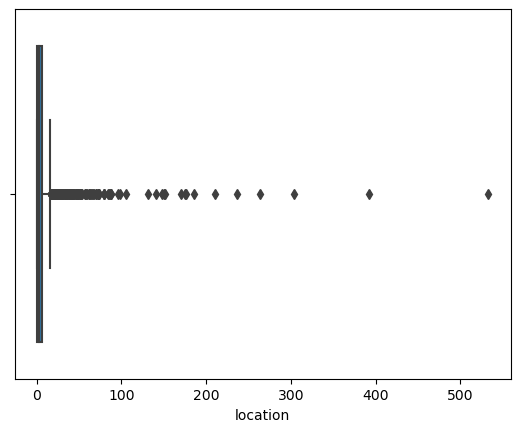

In [186]:
# creons un graphe pour voir plus claire dans la distribution des valeurs de la colonne
sns.boxplot(x = location_stats)

**Note :** 
Beaucoup de valeurs se trouvent dans le range 0-10, on pourrait toutes les mettre dans un seule categorie nommee 'others', dans un soucis de preformance du modele.

In [187]:
# les loations qui ont moins de 10 occurances
location_less_10 = location_stats[location_stats <= 10]

# print (len(location_less_10))
print (location_less_10)

location
1st Block Koramangala    10
Dairy Circle             10
Nagappa Reddy Layout     10
Naganathapura            10
Thyagaraja Nagar         10
                         ..
1 Giri Nagar              1
Kanakapura Road,          1
Kanakapura main  Road     1
Kannur                    1
whitefiled                1
Name: location, Length: 1047, dtype: int64


In [188]:
# Transformation des emplacements avec moins de 10 occurences

df3.location = df3['location'].apply(lambda x : 'others' if x in location_less_10 else x)

# df3.groupby('location')['location'].agg('count').sort_values(ascending= False)
len(df3.location.unique())

241

### Traitement des valeurs extreme total_sqft

In [189]:
df3.total_sqft.describe()

count    13217.000000
mean      1553.998759
std       1237.363071
min          1.000000
25%       1100.000000
50%       1274.000000
75%       1670.000000
max      52272.000000
Name: total_sqft, dtype: float64

**Note:** 
On remarque des valeurs extremes dans les differentes colonnes, par exemple, le total au metre pied à une valeur minimum de 1 et maximum de 52272, ce qui semble etre des valeurs extremes pour une maison.

Nous allons assumer que la valeur normal du metre pied par chambre dans une maison est d'environ 300, en partant sur cette base, une maison avec un ratio de metre pied par chambre inferieur à 300 sera considere comme valeur extreme.

In [190]:
df3[df3.total_sqft / df3.bhk < 300]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,others,6 Bedroom,1020.0,6.0,370.0,6,36274.51
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.33
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.98
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.30
70,others,3 Bedroom,500.0,3.0,100.0,3,20000.00
...,...,...,...,...,...,...,...
13277,others,7 Bedroom,1400.0,7.0,218.0,7,15571.43
13279,others,6 Bedroom,1200.0,5.0,130.0,6,10833.33
13281,Margondanahalli,5 Bedroom,1375.0,5.0,125.0,5,9090.91
13303,Vidyaranyapura,5 Bedroom,774.0,5.0,70.0,5,9043.93


In [191]:
df3.shape

(13217, 7)

In [192]:
# suppression des valeurs extremes < 300
df3 = df3[~(df3.total_sqft / df3.bhk < 300)]
df3.shape

(12460, 7)

### Traitement des valeurs extremes 'price_per_sqft'

In [193]:
df3.price_per_sqft.describe()

count     12460.000000
mean       6308.452132
std        4167.608758
min         267.830000
25%        4210.530000
50%        5294.120000
75%        6916.670000
max      176470.590000
Name: price_per_sqft, dtype: float64

#### Note :
On remarque ici que le prix maximum par sqft est tres haut et eloigne par rapport a la moyenne, 
cela peut etre considere comme des valeurs abberantes car beaucoup trop eloigne de la valeur moyenne de notre population. 
Nous avons besoin de les enlever.

In [194]:
# fonction pour supprimer les valeurs extremes. 
# Nous allons garder que les lignes ou le prix au metre carre est à une 
# deviation standard de la moyenne. 

def remove_outliers_ppst(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduce_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduce_df], ignore_index = True)
    return df_out

df3 = remove_outliers_ppst(df3)
df3.shape

(10246, 7)

#### Note : 
Essayons de voir si le prix des maisons ne sont pas extremes en fonction de la taille des maisons et de leur emplacement, une maison ayant par exemple 2 chambres devrait dans la nombre valoir moins chere qu'une maison ayant 3 chambres dans la meme zone.

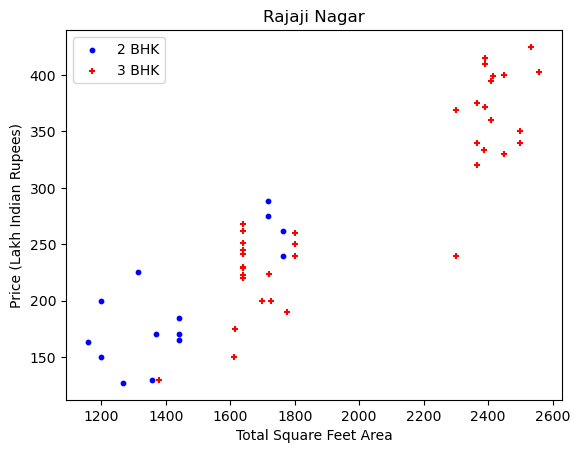

In [195]:
# cette fonction creer un graphique du prix des maisons en fonction de leur nombre de chambres pour une localisation precise.
def plot_scatter_chart(df3,location):
    bhk2 = df3[(df3.location==location) & (df3.bhk==2)]
    bhk3 = df3[(df3.location==location) & (df3.bhk==3)]
    #matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=10)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker = '+' ,color='red',label='3 BHK', s=20)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df3,"Rajaji Nagar")

#### Note : 
Le prix de certaines maisons ayant 2 chambres est plus eleve que le prix des maisons à 3 chambres dans la meme zone, cela peut etre considere comme des erreurs.

Nous allons creer une fonction qui va grouper les valeurs par emplacement et nombres de chambres puis calculer leurs moyennes de prix, le nombre et la deviation standard, et en fonction de ces donnees, elle va supprimer toutes les maisons qui ont un nombres de chambres superieurs et qui ont un prix inferieur à la moyenne de prix d'une maison ayant moyen de chambres.

In [196]:
# definition de la fonction
def remove_bhk_outliers(df):
    exclude_indices = np.array([]) # liste des exclus
    for location, location_df in df.groupby('location'): # groupage par zone
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'): # calcul des metrics
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'): # creation de la liste d'exclusion
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')


In [197]:
# df4
df4 = remove_bhk_outliers(df3)

# application de la fonction
remove_bhk_outliers(df4)

df4.shape


(7315, 7)

In [198]:
df3.shape


(10246, 7)

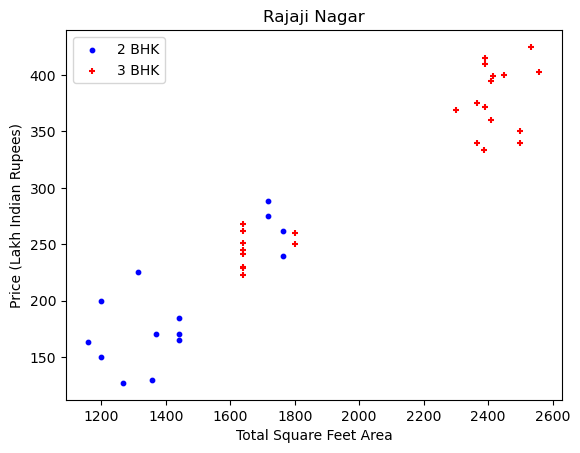

In [199]:
# visualisation de la nouvelle base
plot_scatter_chart(df4,"Rajaji Nagar")

### Traitement des valeurs extremes 'bath'
Le nombre maximum de salle de bains est de 16, essayons de savoir si ces donnees ne sont pas extreme et si il y aurait pas des valeurs extremes au niveau du nmbres de salles de bains, par example si une maisons possede 3 chambres, elle ne peut pas avoir un nombres de salles de bains qui est superieur a 5, on pourrait le considerer comme une valeur extreme.

<Axes: xlabel='bath'>

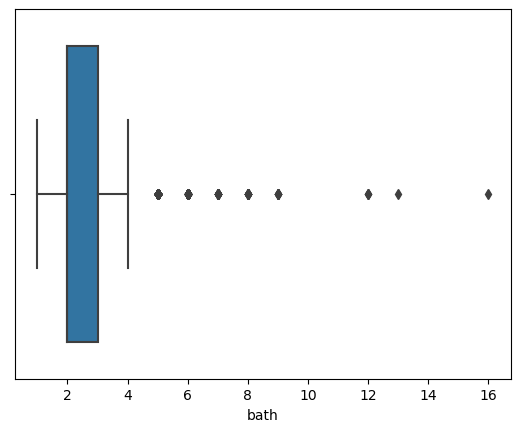

In [200]:
sns.boxplot(x = df4.bath)

In [201]:
df4[df4.bath > 10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5278,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.00
8486,others,10 BHK,12000.0,12.0,525.0,10,4375.00
8576,others,16 BHK,10000.0,16.0,550.0,16,5500.00
9310,others,11 BHK,6000.0,12.0,150.0,11,2500.00
9641,others,13 BHK,5425.0,13.0,275.0,13,5069.12


In [202]:
df4[df4.bath > df4.bhk + 2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.03
5239,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.57
6712,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.03
8411,others,6 BHK,11338.0,9.0,1000.0,6,8819.90


In [203]:
df4.shape

(7315, 7)

#### Note : 
Une maison ayant seulement 4 chambres et 8 salles de bain n'est pas quelque chose dans la norme, donc on peut considere ces points de donnees comme des valeurs extremes. De meme une maison ayant 4 chambres et moins de 6 salles de bain peut aussi etre considere comme tel.

In [204]:
df5 = df4[df4.bath<df4.bhk+2]
df5.shape

(7237, 7)

In [205]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7237 entries, 0 to 10245
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        7237 non-null   object 
 1   size            7237 non-null   object 
 2   total_sqft      7237 non-null   float64
 3   bath            7237 non-null   float64
 4   price           7237 non-null   float64
 5   bhk             7237 non-null   int64  
 6   price_per_sqft  7237 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 452.3+ KB


In [206]:
# nous aurons plus besoion de ces colonnes pour la suite de notre analyse.
df6 = df5.drop(columns=['size','price_per_sqft'])
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7237 entries, 0 to 10245
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7237 non-null   object 
 1   total_sqft  7237 non-null   float64
 2   bath        7237 non-null   float64
 3   price       7237 non-null   float64
 4   bhk         7237 non-null   int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 339.2+ KB


### Encodage de 'location'

In [219]:
# creation des dummies 
dummies = pd.get_dummies(df6.location)
dummies.head(3)

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,others
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [220]:
# concatenation des dummies avec  la base de donnees
df7 = pd.concat([df6,dummies.drop('others',axis='columns')],axis='columns')
df7.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Construction du modele

### Creation des variables

In [222]:
# creation des variables independantes
X = df7.drop(["price", 'location'], axis = 'columns')
X.head()

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [224]:
# Creation de la variable dependante
y = df7.price
y.head()

0    428.0
1    194.0
2    235.0
3    130.0
4    148.0
Name: price, dtype: float64

In [225]:
# creation de train et test dataset
# 80% train, 20% test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=10)

In [226]:
# creation du modele de regression

from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)

0.8544839555267695

### Validation du modele

#### Note : 
Notre modele a un score de 85%, ce qui est raisonable pour notre modele. Nous allons utiliser K fold pour verifier que cette performance est fiable.

In [228]:
# creation d'une validation croisée
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.84873405, 0.85780262, 0.87743107, 0.78528513, 0.80471975])

### Trouver le meilleur modele avec GridSearchCV

#### Note : 
Nous pouvons remarquer que chaque iteration a un score proche de 80%, ce qui est res bon pour un modele mais nous allons essayer de voir si nous ne pouvons pas avoir un meilleur score avec d'autres modeles de regression. Pour se faire, nous allons utiliser 'GridSearchCV'.

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(X,y):
    algos = {
        'linear_regression' : {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False]  # Remplace normalize
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion' : ['mse','friedman_mse'],
                'splitter': ['best','random']
            }
        }
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X,y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\LENOVO\anaconda3\Lib\site-pack

,model,best_score,best_params
0,linear_regression,0.835197,{'fit_intercept': False}
1,lasso,0.698142,"{'alpha': 2, 'selection': 'cyclic'}"
2,decision_tree,0.743243,"{'criterion': 'friedman_mse', 'splitter': 'best'}"


In [240]:
# appel de la fonction

find_best_model_using_gridsearchcv(X,y)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\LENOVO\anaconda3\Lib\site-pack

,model,best_score,best_params
0,linear_regression,0.835197,{'fit_intercept': False}
1,lasso,0.698142,"{'alpha': 2, 'selection': 'cyclic'}"
2,decision_tree,0.724224,"{'criterion': 'friedman_mse', 'splitter': 'best'}"


In [244]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

def find_best_model_using_gridsearchcv1(X, y):
    # Standardisation des données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False]  # Remplace normalize
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],  # 'mse' est obsolète dans les versions récentes
                'splitter': ['best', 'random']
            }
        }
    }
    
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X_scaled, y)  # Utilisation des données standardisées
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])


In [245]:
find_best_model_using_gridsearchcv1(X,y)

,model,best_score,best_params
0,linear_regression,0.833453,{'fit_intercept': True}
1,lasso,0.802741,"{'alpha': 1, 'selection': 'random'}"
2,decision_tree,0.739948,"{'criterion': 'friedman_mse', 'splitter': 'best'}"


#### Note : 
Le meilleur modele est donc le moodele de regression lineaire avec un score de 83% de precision, nous allons tester ce modele avec des predictions de prix.

### Test du modele

In [246]:
# cette fonction va essayer de predire le prix d'une maison en se basant
# sur les donnees de la maison comme le nombres de chambres, de toilettes...

def predict_price(location,sqft,bath,bhk):    
    loc_index = np.where(X.columns==location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1

    return lr_clf.predict([x])[0]

In [ ]:
# appel de la fonction
predict_price('1st Phase JP Nagar',1000, 2, 2)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


84.45076631383841

In [252]:
predict_price('1st Phase JP Nagar',1000, 2, 3)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


83.18369788205743

In [249]:
predict_price('Indira Nagar',1000, 2, 2)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


195.10709123085064

## Conclusion

Cette étude sur la prédiction des prix immobiliers à Bengaluru nous a permis de développer un modèle de régression capable d'estimer les prix des propriétés avec une précision satisfaisante. À travers ce projet, nous avons pu :

1. **Comprendre le marché** : Notre analyse a révélé les dynamiques complexes du marché immobilier de Bengaluru et les facteurs clés qui influencent les prix.

2. **Développer un modèle prédictif** : Le modèle de régression créé permet d'estimer les prix des propriétés en fonction de diverses caractéristiques, offrant ainsi un outil précieux pour les acteurs du marché.

3. **Identifier les facteurs déterminants** : Nous avons mis en évidence l'importance de certains facteurs comme la localisation, la surface habitable, et d'autres caractéristiques qui impactent significativement les prix.

### Limites et Perspectives

- Le modèle pourrait être amélioré avec des données plus récentes et plus détaillées
- L'intégration de facteurs économiques et démographiques pourrait enrichir l'analyse
- Une mise à jour régulière du modèle serait nécessaire pour maintenir sa pertinence

Cette étude constitue une base solide pour comprendre et prédire les prix immobiliers à Bengaluru, tout en offrant des perspectives d'amélioration pour des analyses futures.